In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

In [ ]:
# Solo i 2 modelli con ordine invertito
INVERTED_MODELS = {
    'granite3.1-moe:3b': 'granite3.1-moe_3b',
    'qwen3:4b-instruct': 'qwen3_4b-instruct'
}

# Nomi semplificati
INVERTED_MODEL_DISPLAY_NAMES = {
    'granite3.1-moe_3b': 'Granite 3.1 MoE 3B',
    'qwen3_4b-instruct': 'Qwen3 4B'
}

# Task names per ordine invertito
TASK_NAMES = {
    1: "json_sentiment_emotion_topic_ner_translation",
    2: "json_sentiment_emotion_topic_ner", 
    3: "json_sentiment_emotion_topic",
    4: "json_sentiment_emotion",
    5: "json_sentiment",
    6: "json_only"
}

BASE_DIR = "../Output Performance Degradation Analysis"

# Colori per i modelli
INVERTED_MODEL_COLORS = {
    'granite3.1-moe_3b': '#8c564b',     # Marrone
    'qwen3_4b-instruct': '#1f77b4'      # Blu
}

# Colori per le metriche (stessi dell'originale)
METRIC_COLORS = {
    'json_em': '#1f77b4',
    'bleu_translate': '#ff7f0e',
    'em_sentiment': '#2ca02c',
    'em_emotion': '#d62728',
    'em_topic': '#9467bd',
    'f1_ner': '#8c564b'
}

print(f"Configurazione completata per {len(INVERTED_MODELS)} modelli invertiti")
print("Ordine task invertito:")
for task_num, task_name in TASK_NAMES.items():
    print(f"  Task {task_num}: {task_name}")

In [ ]:
def load_inverted_model_data():
    """Carica i dati dei modelli invertiti dai CSV summary."""
    inverted_data = {}
    
    for model_name, model_clean in INVERTED_MODELS.items():
        csv_path = f"{BASE_DIR}/evaluation_summary_invert_{model_clean}_6tasks.csv"
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                inverted_data[model_clean] = df
                print(f"✓ Caricato invertito: {model_name} ({len(df)} righe)")
            except Exception as e:
                print(f"❌ Errore caricando {model_name}: {e}")
        else:
            print(f"❌ File non trovato: {csv_path}")
    
    return inverted_data

In [ ]:
def get_final_performance_data_inverted(all_data):
    """Estrae i dati delle performance finali per ogni modello - ORDINE INVERTITO."""
    final_data = {}
    
    # Task metrics per ordine invertito - TUTTE le metriche disponibili per ogni task
    task_metrics = {
        1: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],  # Più complesso
        2: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        3: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        4: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        5: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        6: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner']   # Più semplice
    }
    
    for model_name, df in all_data.items():
        model_data = {}
        
        for task in range(1, 7):
            task_df = df[df['task_number'] == task]
            if not task_df.empty:
                last_row = task_df.iloc[-1]
                
                task_data = {}
                for metric in task_metrics[task]:
                    value = last_row[metric] if metric in last_row and pd.notna(last_row[metric]) else 0
                    task_data[metric] = value
                
                model_data[task] = task_data
        
        final_data[model_name] = model_data
    
    return final_data

In [ ]:
def create_final_performance_comparison_inverted(final_data, output_dir):
    """Crea grafici delle performance finali per ordine invertito."""
    
    # Task metrics ALLINEATI con get_final_performance_data_inverted
    task_metrics = {
        1: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],  # 6 metriche
        2: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],  # 6 metriche
        3: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],  # 6 metriche
        4: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],  # 6 metriche
        5: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],  # 6 metriche
        6: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), 
            ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')]   # 6 metriche
    }
    
    model_names = list(final_data.keys())
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('Final Performance Comparison - Inverted Task Order', fontsize=18, fontweight='bold')
    
    for idx, model_name in enumerate(model_names):
        ax = axes[idx]
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        
        model_data = final_data[model_name]
        
        current_position = 0
        bar_width = 0.6
        group_spacing = 1.5
        all_positions = []
        all_labels = []
        
        for task in range(1, 7):
            task_start_pos = current_position
            
            for i, (metric_key, metric_label) in enumerate(task_metrics[task]):
                pos = current_position
                
                value = 0
                if task in model_data and metric_key in model_data[task]:
                    value = model_data[task][metric_key]
                
                color = METRIC_COLORS[metric_key]
                
                bar = ax.bar(pos, value, width=bar_width, color=color, alpha=0.8)
                
                if value > 0:
                    ax.text(pos, value + 1, f'{value:.1f}', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
                
                current_position += bar_width + 0.2
            
            task_center = task_start_pos + (len(task_metrics[task]) * (bar_width + 0.2) - 0.2) / 2
            all_positions.append(task_center)
            all_labels.append(f'Task {task}')
            
            current_position += group_spacing
        
        ax.set_xticks(all_positions)
        ax.set_xticklabels(all_labels, rotation=0, ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{model_display}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Performance (%)', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/multi_model_final_performance_comparison_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico comparativo invertito salvato")

def create_overall_degradation_chart_inverted(final_data, output_dir):
    """Crea grafico di performance change per ordine invertito."""
    
    degradation_results = {}
    
    # Metriche per calcolo degradazione - ORDINE INVERTITO (da Task 1 a Task 6)
    metrics_for_degradation = {
        'json_em': (1, 6),          
        'em_sentiment': (1, 5),     
        'em_emotion': (1, 4),
        'em_topic': (1, 3),
        'f1_ner': (1, 2)
        # bleu_translate solo in Task 1, non possiamo calcolare degradazione
    }
    
    for model_name, model_data in final_data.items():
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        degradations = []
        
        for metric, (start_task, end_task) in metrics_for_degradation.items():
            if start_task in model_data and end_task in model_data:
                start_value = model_data[start_task].get(metric, 0)  # Task più complesso
                end_value = model_data[end_task].get(metric, 0)      # Task più semplice
                
                if start_value > 0:
                    # Formula: ((finale - iniziale) / iniziale) * 100
                    change_pct = ((end_value - start_value) / start_value) * 100
                    degradations.append(change_pct)
                    status = "miglioramento" if change_pct > 0 else "degradazione"
                    print(f"{model_display} - {metric}: {start_value:.1f}% → {end_value:.1f}% ({status}: {change_pct:+.1f}%)")
        
        if degradations:
            avg_change = sum(degradations) / len(degradations)
            degradation_results[model_display] = {
                'avg_change': avg_change,
                'individual_changes': degradations,
                'n_metrics': len(degradations)
            }
            status = "miglioramento" if avg_change > 0 else "degradazione"
            print(f"{model_display} - {status.title()} medio: {avg_change:+.1f}%\n")
    
    # Crea grafico
    sorted_models = sorted(degradation_results.items(), 
                          key=lambda x: x[1]['avg_change'])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    models = [item[0] for item in sorted_models]
    values = [item[1]['avg_change'] for item in sorted_models]
    
    colors = []
    for val in values:
        if val < -20:
            colors.append('#c0392b')
        elif val < -10:
            colors.append('#e74c3c')
        elif val < -5:
            colors.append('#f39c12')
        elif val < 0:
            colors.append('#f1c40f')
        else:
            colors.append('#27ae60')
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=2.5, width=0.6)
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val >= 0:
            y_pos = bar.get_height() + max(abs(max(values)), abs(min(values))) * 0.02
            va = 'bottom'
        else:
            y_pos = bar.get_height() - max(abs(max(values)), abs(min(values))) * 0.02
            va = 'top'
            
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', va=va, 
                fontsize=12, fontweight='bold', color='#2c3e50')
    
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.8)
    
    ax.set_title('Performance Change by Model - Inverted Task Order\n(From Complex Task 1 to Simple Task 6)', 
                fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
    ax.set_xlabel('Model', fontsize=14, fontweight='bold', color='#34495e')
    ax.set_ylabel('Average Performance Change (%)', fontsize=14, fontweight='bold', color='#34495e')
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    if values:
        y_max = max(abs(max(values)), abs(min(values))) * 1.2
        ax.set_ylim(-y_max, y_max)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
    ax.set_axisbelow(True)
    
    # Legenda semplificata
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#c0392b', label='Severe Degradation (< -20%)'),
        Patch(facecolor='#e74c3c', label='High Degradation (-10% to -20%)'),
        Patch(facecolor='#f39c12', label='Medium Degradation (-5% to -10%)'),
        Patch(facecolor='#f1c40f', label='Low Degradation (0% to -5%)'),
        Patch(facecolor='#27ae60', label='Improvement (> 0%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
             fontsize=10, framealpha=0.95, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overall_model_performance_change_analysis_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico performance change invertito salvato")

Configurazione completata per 2 modelli invertiti
Ordine task invertito:
  Task 1: json_sentiment_emotion_topic_ner_translation
  Task 2: json_sentiment_emotion_topic_ner
  Task 3: json_sentiment_emotion_topic
  Task 4: json_sentiment_emotion
  Task 5: json_sentiment
  Task 6: json_only
ANALISI PERFORMANCE - ORDINE INVERTITO

📥 Caricamento dati invertiti...
✓ Caricato invertito: granite3.1-moe:3b (21 righe)
✓ Caricato invertito: qwen3:4b-instruct (21 righe)

📈 Elaborazione dati invertiti...
📁 Directory output: ../Output Performance Degradation Analysis

GENERAZIONE GRAFICI ORDINE INVERTITO

🎨 1. Grafico comparativo performance finali invertito...


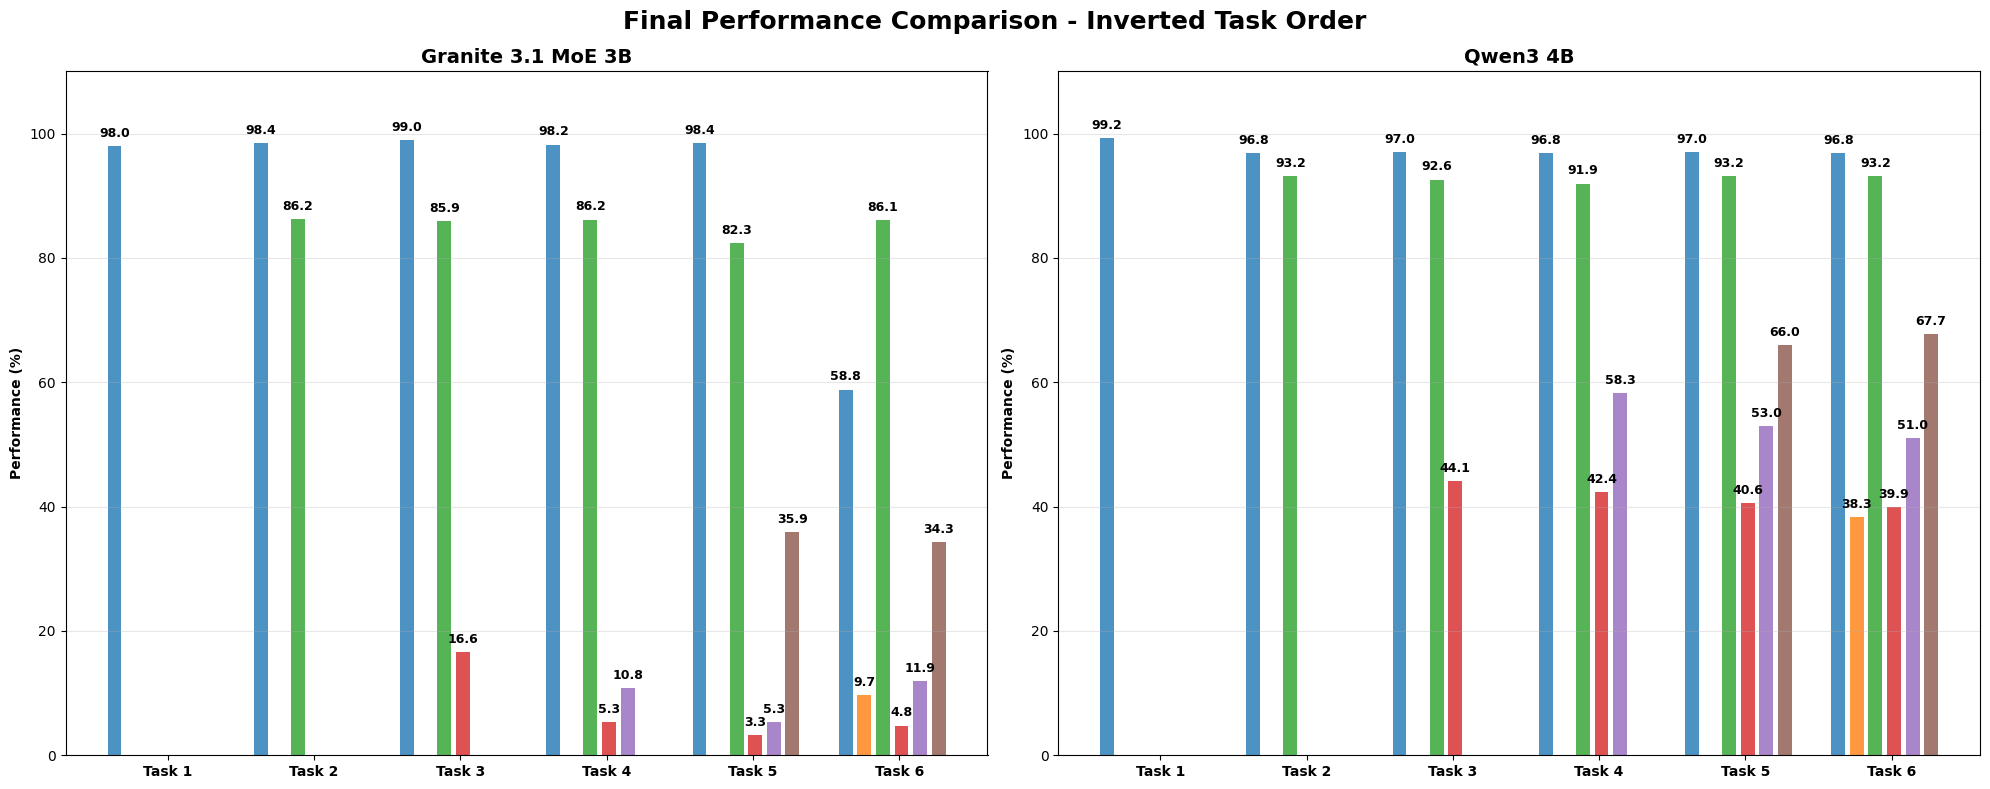

✅ Grafico comparativo invertito salvato

🎨 2. Grafico performance change invertito...
Granite 3.1 MoE 3B - json_em: 98.0% → 58.8% (degradazione: -40.0%)
Granite 3.1 MoE 3B - Degradazione medio: -40.0%

Qwen3 4B - json_em: 99.2% → 96.8% (degradazione: -2.4%)
Qwen3 4B - Degradazione medio: -2.4%



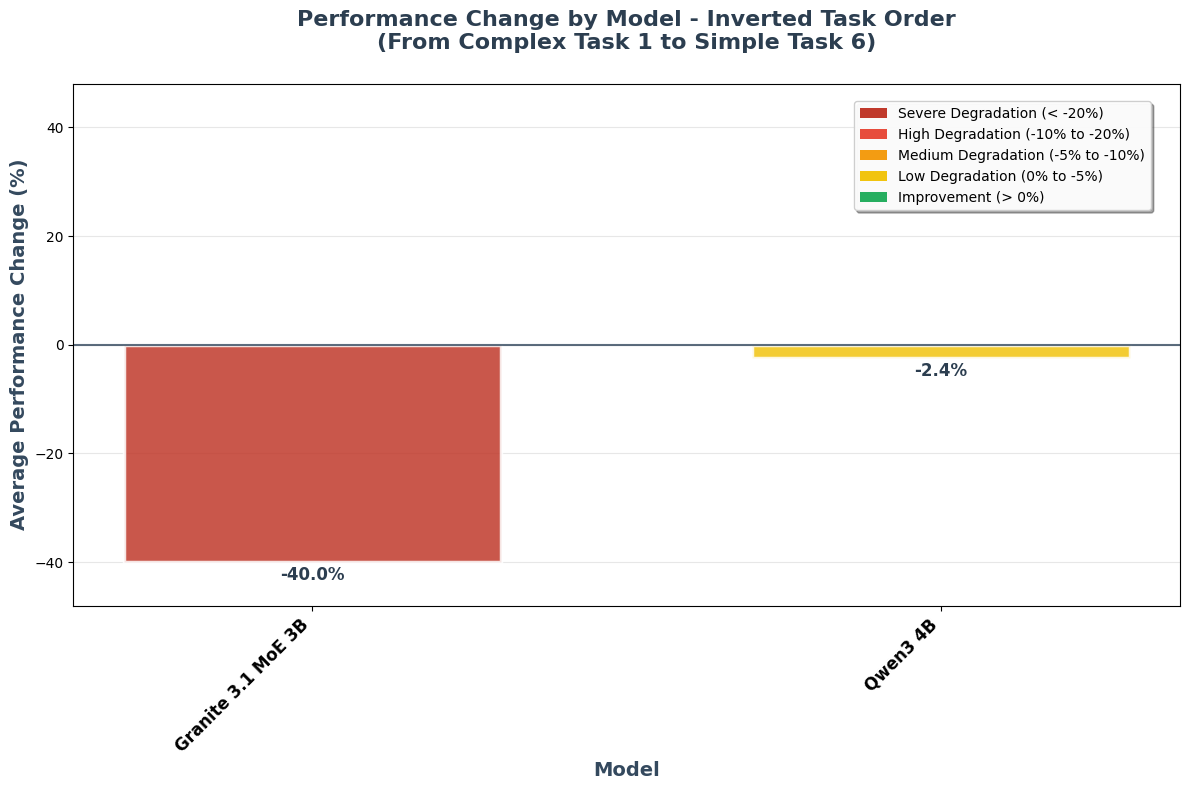

✅ Grafico performance change invertito salvato

💾 Salvataggio riassunto dati...
✅ CSV riassuntivo salvato: ../Output Performance Degradation Analysis/inverted_model_summary.csv

✅ ANALISI ORDINE INVERTITO COMPLETATA!
📁 Output salvato in: ../Output Performance Degradation Analysis/

📊 File generati:
     - multi_model_final_performance_comparison_inverted.png
     - overall_model_performance_change_analysis_inverted.png
     - inverted_model_summary.csv


In [3]:
def main():
    print("=" * 80)
    print("ANALISI PERFORMANCE - ORDINE INVERTITO")
    print("=" * 80)
    
    # Carica dati
    print("\n📥 Caricamento dati invertiti...")
    inverted_data = load_inverted_model_data()
    
    if not inverted_data:
        print("❌ Nessun dato invertito trovato!")
        return
    
    # Elabora dati
    print("\n📈 Elaborazione dati invertiti...")
    inverted_final = get_final_performance_data_inverted(inverted_data)
    
    # Crea directory output
    output_dir = f"{BASE_DIR}"
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Directory output: {output_dir}")
    
    print("\n" + "="*60)
    print("GENERAZIONE GRAFICI ORDINE INVERTITO")
    print("="*60)
    
    # Grafici per ordine invertito
    print("\n🎨 1. Grafico comparativo performance finali invertito...")
    create_final_performance_comparison_inverted(inverted_final, output_dir)
    
    print("\n🎨 2. Grafico performance change invertito...")
    create_overall_degradation_chart_inverted(inverted_final, output_dir)
    
    # Salva riassunto
    print("\n💾 Salvataggio riassunto dati...")
    summary_rows = []
    for model_name, model_data in inverted_final.items():
        for task, metrics in model_data.items():
            for metric, value in metrics.items():
                summary_rows.append({
                    'model': INVERTED_MODEL_DISPLAY_NAMES[model_name],
                    'task': task,
                    'metric': metric,
                    'value': value,
                    'order': 'inverted'
                })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f'{output_dir}/inverted_model_summary.csv', index=False)
    print(f"✅ CSV riassuntivo salvato: {output_dir}/inverted_model_summary.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANALISI ORDINE INVERTITO COMPLETATA!")
    print("=" * 80)
    print(f"📁 Output salvato in: {output_dir}/")
    print("\n📊 File generati:")
    print("     - multi_model_final_performance_comparison_inverted.png")
    print("     - overall_model_performance_change_analysis_inverted.png")
    print("     - inverted_model_summary.csv")

if __name__ == "__main__":
    main()

Configurazione completata per 2 modelli invertiti
Ordine task invertito:
  Task 1: json_only
  Task 2: json_sentiment
  Task 3: json_sentiment_emotion
  Task 4: json_sentiment_emotion_topic
  Task 5: json_sentiment_emotion_topic_ner
  Task 6: json_sentiment_emotion_topic_ner_translation
ANALISI PERFORMANCE - ORDINE INVERTITO

📥 Caricamento dati invertiti...
✓ Caricato invertito: granite3.1-moe:3b (21 righe)
✓ Caricato invertito: qwen3:4b-instruct (21 righe)

📈 Elaborazione dati invertiti...
📁 Directory output: ../Output Performance Degradation Analysis

GENERAZIONE GRAFICI ORDINE INVERTITO

🎨 1. Grafico comparativo performance finali invertito...


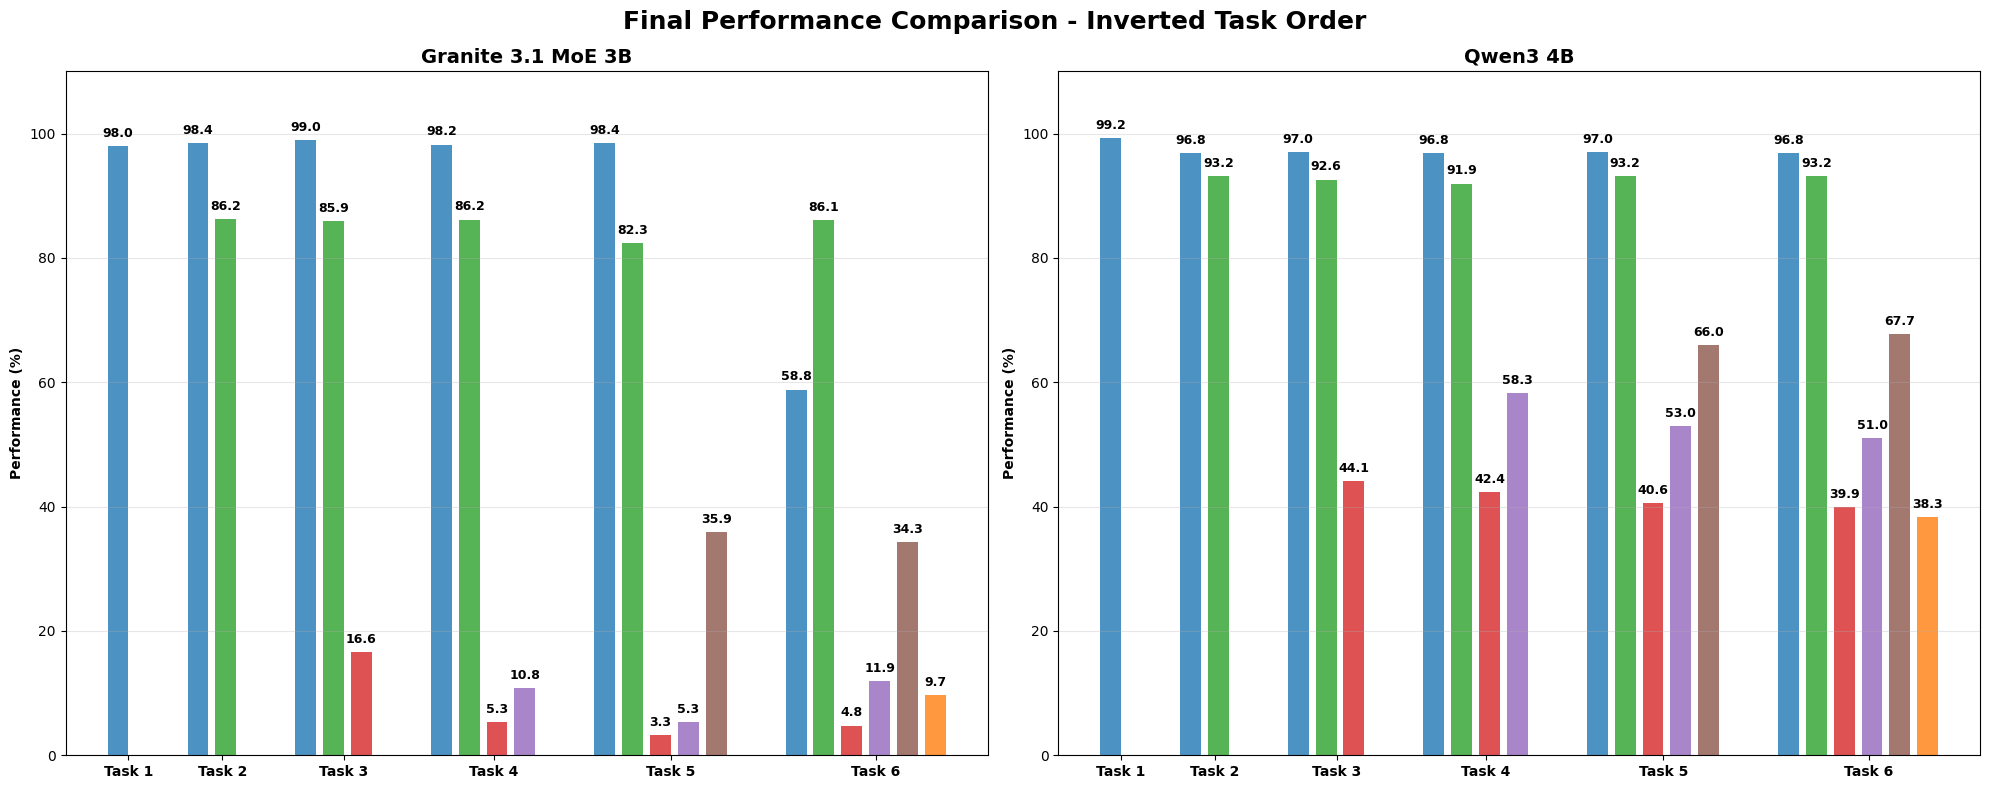

✅ Grafico comparativo invertito salvato

🎨 2. Grafico performance change invertito...
Granite 3.1 MoE 3B - json_em: 98.0% → 58.8% (degradazione: -40.0%)
Granite 3.1 MoE 3B - em_sentiment: 86.2% → 86.1% (degradazione: -0.1%)
Granite 3.1 MoE 3B - em_emotion: 16.6% → 4.8% (degradazione: -71.3%)
Granite 3.1 MoE 3B - em_topic: 10.8% → 11.9% (miglioramento: +10.3%)
Granite 3.1 MoE 3B - f1_ner: 35.9% → 34.3% (degradazione: -4.4%)
Granite 3.1 MoE 3B - Degradazione medio: -21.1%

Qwen3 4B - json_em: 99.2% → 96.8% (degradazione: -2.4%)
Qwen3 4B - em_sentiment: 93.2% → 93.2% (degradazione: +0.0%)
Qwen3 4B - em_emotion: 44.1% → 39.9% (degradazione: -9.6%)
Qwen3 4B - em_topic: 58.3% → 51.0% (degradazione: -12.4%)
Qwen3 4B - f1_ner: 66.0% → 67.7% (miglioramento: +2.6%)
Qwen3 4B - Degradazione medio: -4.4%



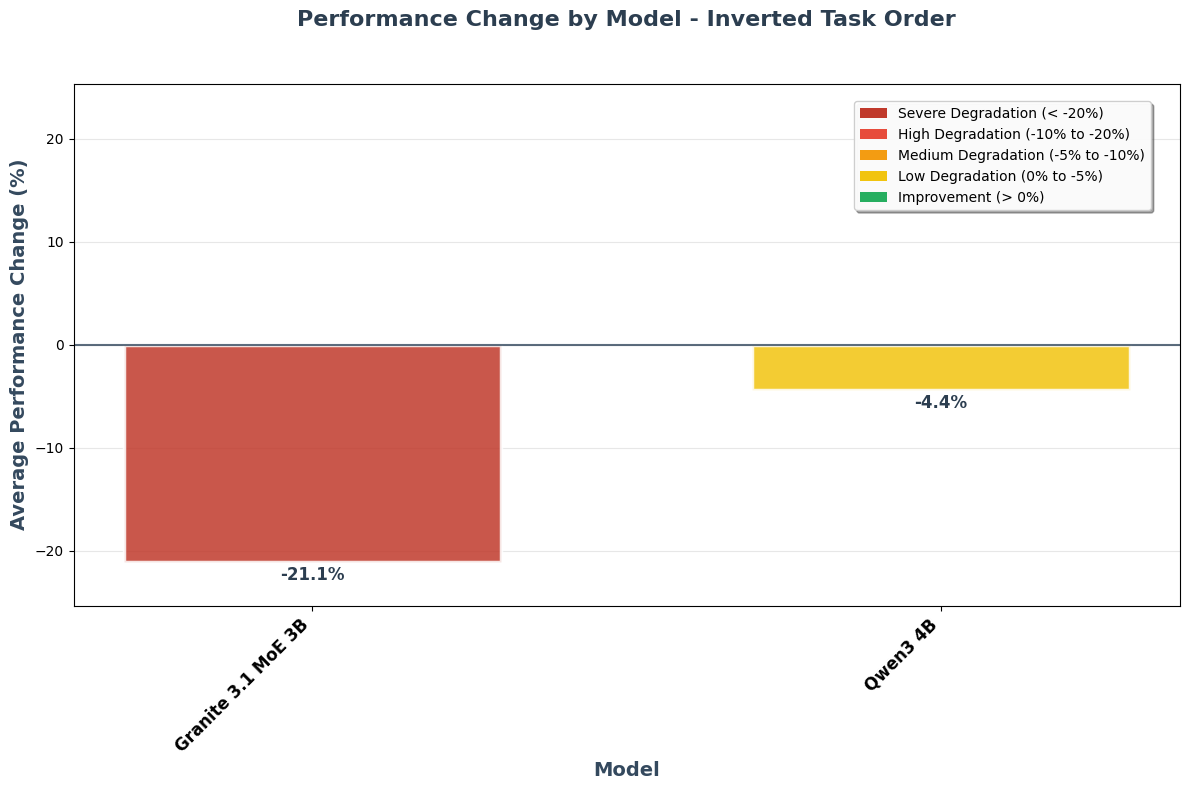

✅ Grafico performance change invertito salvato

💾 Salvataggio riassunto dati...
✅ CSV riassuntivo salvato: ../Output Performance Degradation Analysis/inverted_model_summary.csv

✅ ANALISI ORDINE INVERTITO COMPLETATA!
📁 Output salvato in: ../Output Performance Degradation Analysis/

📊 File generati:
     - multi_model_final_performance_comparison_inverted.png
     - overall_model_performance_change_analysis_inverted.png
     - inverted_model_summary.csv


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

# =============================================================================
# CONFIGURAZIONE MODELLI INVERTITI
# =============================================================================

# Solo i 2 modelli con ordine invertito
INVERTED_MODELS = {
    'granite3.1-moe:3b': 'granite3.1-moe_3b',
    'qwen3:4b-instruct': 'qwen3_4b-instruct'
}

# Nomi semplificati
INVERTED_MODEL_DISPLAY_NAMES = {
    'granite3.1-moe_3b': 'Granite 3.1 MoE 3B',
    'qwen3_4b-instruct': 'Qwen3 4B'
}

# Task names per ordine invertito - ORDINE CORRETTO
TASK_NAMES = {
    1: "json_only",
    2: "json_sentiment", 
    3: "json_sentiment_emotion",
    4: "json_sentiment_emotion_topic",
    5: "json_sentiment_emotion_topic_ner",
    6: "json_sentiment_emotion_topic_ner_translation"
}

BASE_DIR = "../Output Performance Degradation Analysis"

# Colori per i modelli
INVERTED_MODEL_COLORS = {
    'granite3.1-moe_3b': '#8c564b',     # Marrone
    'qwen3_4b-instruct': '#1f77b4'      # Blu
}

# Colori per le metriche (stessi dell'originale)
METRIC_COLORS = {
    'json_em': '#1f77b4',
    'bleu_translate': '#ff7f0e',
    'em_sentiment': '#2ca02c',
    'em_emotion': '#d62728',
    'em_topic': '#9467bd',
    'f1_ner': '#8c564b'
}

print(f"Configurazione completata per {len(INVERTED_MODELS)} modelli invertiti")
print("Ordine task invertito:")
for task_num, task_name in TASK_NAMES.items():
    print(f"  Task {task_num}: {task_name}")

# =============================================================================
# FUNZIONI DI CARICAMENTO DATI
# =============================================================================

def load_inverted_model_data():
    """Carica i dati dei modelli invertiti dai CSV summary."""
    inverted_data = {}
    
    for model_name, model_clean in INVERTED_MODELS.items():
        csv_path = f"{BASE_DIR}/evaluation_summary_invert_{model_clean}_6tasks.csv"
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                inverted_data[model_clean] = df
                print(f"✓ Caricato invertito: {model_name} ({len(df)} righe)")
            except Exception as e:
                print(f"❌ Errore caricando {model_name}: {e}")
        else:
            print(f"❌ File non trovato: {csv_path}")
    
    return inverted_data

# =============================================================================
# FUNZIONI DI ELABORAZIONE DATI (ADATTATE PER ORDINE INVERTITO)
# =============================================================================

def get_final_performance_data_inverted(all_data):
    """Estrae i dati delle performance finali per ogni modello - ORDINE INVERTITO."""
    final_data = {}
    
    # Task metrics per ordine invertito - ORDINE CORRETTO
    task_metrics = {
        1: ['json_em'],  # Più semplice
        2: ['json_em', 'em_sentiment'],
        3: ['json_em', 'em_sentiment', 'em_emotion'],
        4: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic'],
        5: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        6: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner', 'bleu_translate']  # Più complesso
    }
    
    for model_name, df in all_data.items():
        model_data = {}
        
        for task in range(1, 7):
            task_df = df[df['task_number'] == task]
            if not task_df.empty:
                last_row = task_df.iloc[-1]
                
                task_data = {}
                for metric in task_metrics[task]:
                    value = last_row[metric] if metric in last_row and pd.notna(last_row[metric]) else 0
                    task_data[metric] = value
                
                model_data[task] = task_data
        
        final_data[model_name] = model_data
    
    return final_data

# =============================================================================
# GRAFICI PER ORDINE INVERTITO
# =============================================================================

def create_final_performance_comparison_inverted(final_data, output_dir):
    """Crea grafici delle performance finali per ordine invertito."""
    
    # Task metrics CORRETTI per ordine invertito
    task_metrics = {
        1: [('json_em', 'JSON EM')],  # Più semplice
        2: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM')],
        3: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM')],
        4: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM')],
        5: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],
        6: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1'), ('bleu_translate', 'BLEU Trans')]  # Più complesso
    }
    
    model_names = list(final_data.keys())
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('Final Performance Comparison - Inverted Task Order', fontsize=18, fontweight='bold')
    
    for idx, model_name in enumerate(model_names):
        ax = axes[idx]
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        
        model_data = final_data[model_name]
        
        current_position = 0
        bar_width = 0.6
        group_spacing = 1.5
        all_positions = []
        all_labels = []
        
        for task in range(1, 7):
            task_start_pos = current_position
            
            for i, (metric_key, metric_label) in enumerate(task_metrics[task]):
                pos = current_position
                
                value = 0
                if task in model_data and metric_key in model_data[task]:
                    value = model_data[task][metric_key]
                
                color = METRIC_COLORS[metric_key]
                
                bar = ax.bar(pos, value, width=bar_width, color=color, alpha=0.8)
                
                if value > 0:
                    ax.text(pos, value + 1, f'{value:.1f}', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
                
                current_position += bar_width + 0.2
            
            task_center = task_start_pos + (len(task_metrics[task]) * (bar_width + 0.2) - 0.2) / 2
            all_positions.append(task_center)
            all_labels.append(f'Task {task}')
            
            current_position += group_spacing
        
        ax.set_xticks(all_positions)
        ax.set_xticklabels(all_labels, rotation=0, ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{model_display}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Performance (%)', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/multi_model_final_performance_comparison_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico comparativo invertito salvato")

def create_overall_degradation_chart_inverted(final_data, output_dir):
    """Crea grafico di performance change per ordine invertito."""
    
    degradation_results = {}
    
    # Metriche per calcolo degradazione - ORDINE INVERTITO CORRETTO (da Task 1 semplice a Task 6 complesso)
    metrics_for_degradation = {
        'json_em': (1, 6),          # Da semplice (1) a complesso (6) 
        'em_sentiment': (2, 6),     # Da quando appare per la prima volta
        'em_emotion': (3, 6),
        'em_topic': (4, 6),
        'f1_ner': (5, 6)
        # bleu_translate solo in Task 6, non possiamo calcolare degradazione
    }
    
    for model_name, model_data in final_data.items():
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        degradations = []
        
        for metric, (start_task, end_task) in metrics_for_degradation.items():
            if start_task in model_data and end_task in model_data:
                start_value = model_data[start_task].get(metric, 0)  # Task più semplice
                end_value = model_data[end_task].get(metric, 0)      # Task più complesso
                
                if start_value > 0:
                    # Formula: ((finale - iniziale) / iniziale) * 100
                    change_pct = ((end_value - start_value) / start_value) * 100
                    degradations.append(change_pct)
                    status = "miglioramento" if change_pct > 0 else "degradazione"
                    print(f"{model_display} - {metric}: {start_value:.1f}% → {end_value:.1f}% ({status}: {change_pct:+.1f}%)")
        
        if degradations:
            avg_change = sum(degradations) / len(degradations)
            degradation_results[model_display] = {
                'avg_change': avg_change,
                'individual_changes': degradations,
                'n_metrics': len(degradations)
            }
            status = "miglioramento" if avg_change > 0 else "degradazione"
            print(f"{model_display} - {status.title()} medio: {avg_change:+.1f}%\n")
    
    # Crea grafico
    sorted_models = sorted(degradation_results.items(), 
                          key=lambda x: x[1]['avg_change'])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    models = [item[0] for item in sorted_models]
    values = [item[1]['avg_change'] for item in sorted_models]
    
    colors = []
    for val in values:
        if val < -20:
            colors.append('#c0392b')
        elif val < -10:
            colors.append('#e74c3c')
        elif val < -5:
            colors.append('#f39c12')
        elif val < 0:
            colors.append('#f1c40f')
        else:
            colors.append('#27ae60')
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=2.5, width=0.6)
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val >= 0:
            y_pos = bar.get_height() + max(abs(max(values)), abs(min(values))) * 0.02
            va = 'bottom'
        else:
            y_pos = bar.get_height() - max(abs(max(values)), abs(min(values))) * 0.02
            va = 'top'
            
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', va=va, 
                fontsize=12, fontweight='bold', color='#2c3e50')
    
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.8)
    
    ax.set_title('Performance Change by Model - Inverted Task Order\n', 
                fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
    ax.set_xlabel('Model', fontsize=14, fontweight='bold', color='#34495e')
    ax.set_ylabel('Average Performance Change (%)', fontsize=14, fontweight='bold', color='#34495e')
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    if values:
        y_max = max(abs(max(values)), abs(min(values))) * 1.2
        ax.set_ylim(-y_max, y_max)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
    ax.set_axisbelow(True)
    
    # Legenda semplificata
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#c0392b', label='Severe Degradation (< -20%)'),
        Patch(facecolor='#e74c3c', label='High Degradation (-10% to -20%)'),
        Patch(facecolor='#f39c12', label='Medium Degradation (-5% to -10%)'),
        Patch(facecolor='#f1c40f', label='Low Degradation (0% to -5%)'),
        Patch(facecolor='#27ae60', label='Improvement (> 0%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
             fontsize=10, framealpha=0.95, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overall_model_performance_change_analysis_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico performance change invertito salvato")

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    print("=" * 80)
    print("ANALISI PERFORMANCE - ORDINE INVERTITO")
    print("=" * 80)
    
    # Carica dati
    print("\n📥 Caricamento dati invertiti...")
    inverted_data = load_inverted_model_data()
    
    if not inverted_data:
        print("❌ Nessun dato invertito trovato!")
        return
    
    # Elabora dati
    print("\n📈 Elaborazione dati invertiti...")
    inverted_final = get_final_performance_data_inverted(inverted_data)
    
    # Crea directory output
    output_dir = f"{BASE_DIR}"
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Directory output: {output_dir}")
    
    print("\n" + "="*60)
    print("GENERAZIONE GRAFICI ORDINE INVERTITO")
    print("="*60)
    
    # Grafici per ordine invertito
    print("\n🎨 1. Grafico comparativo performance finali invertito...")
    create_final_performance_comparison_inverted(inverted_final, output_dir)
    
    print("\n🎨 2. Grafico performance change invertito...")
    create_overall_degradation_chart_inverted(inverted_final, output_dir)
    
    # Salva riassunto
    print("\n💾 Salvataggio riassunto dati...")
    summary_rows = []
    for model_name, model_data in inverted_final.items():
        for task, metrics in model_data.items():
            for metric, value in metrics.items():
                summary_rows.append({
                    'model': INVERTED_MODEL_DISPLAY_NAMES[model_name],
                    'task': task,
                    'metric': metric,
                    'value': value,
                    'order': 'inverted'
                })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f'{output_dir}/inverted_model_summary.csv', index=False)
    print(f"✅ CSV riassuntivo salvato: {output_dir}/inverted_model_summary.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANALISI ORDINE INVERTITO COMPLETATA!")
    print("=" * 80)
    print(f"📁 Output salvato in: {output_dir}/")
    print("\n📊 File generati:")
    print("     - multi_model_final_performance_comparison_inverted.png")
    print("     - overall_model_performance_change_analysis_inverted.png")
    print("     - inverted_model_summary.csv")

if __name__ == "__main__":
    main()

Configurazione completata per 2 modelli invertiti
Ordine task invertito:
  Task 1: json_only
  Task 2: json_sentiment
  Task 3: json_sentiment_emotion
  Task 4: json_sentiment_emotion_topic
  Task 5: json_sentiment_emotion_topic_ner
  Task 6: json_sentiment_emotion_topic_ner_translation
ANALISI PERFORMANCE - ORDINE INVERTITO

📥 Caricamento dati invertiti...
✓ Caricato invertito: granite3.1-moe:3b (21 righe)
✓ Caricato invertito: qwen3:4b-instruct (21 righe)

📈 Elaborazione dati invertiti...
📁 Directory output: ../Output Performance Degradation Analysis

GENERAZIONE GRAFICI ORDINE INVERTITO

📋 0. Tabella modelli utilizzati...


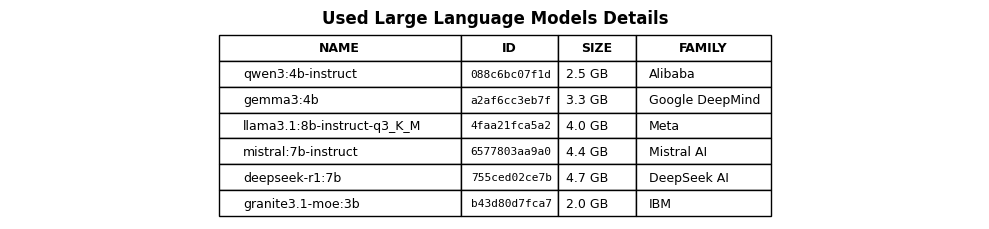

Tabella modelli salvata

🎨 1. Grafico comparativo performance finali invertito...


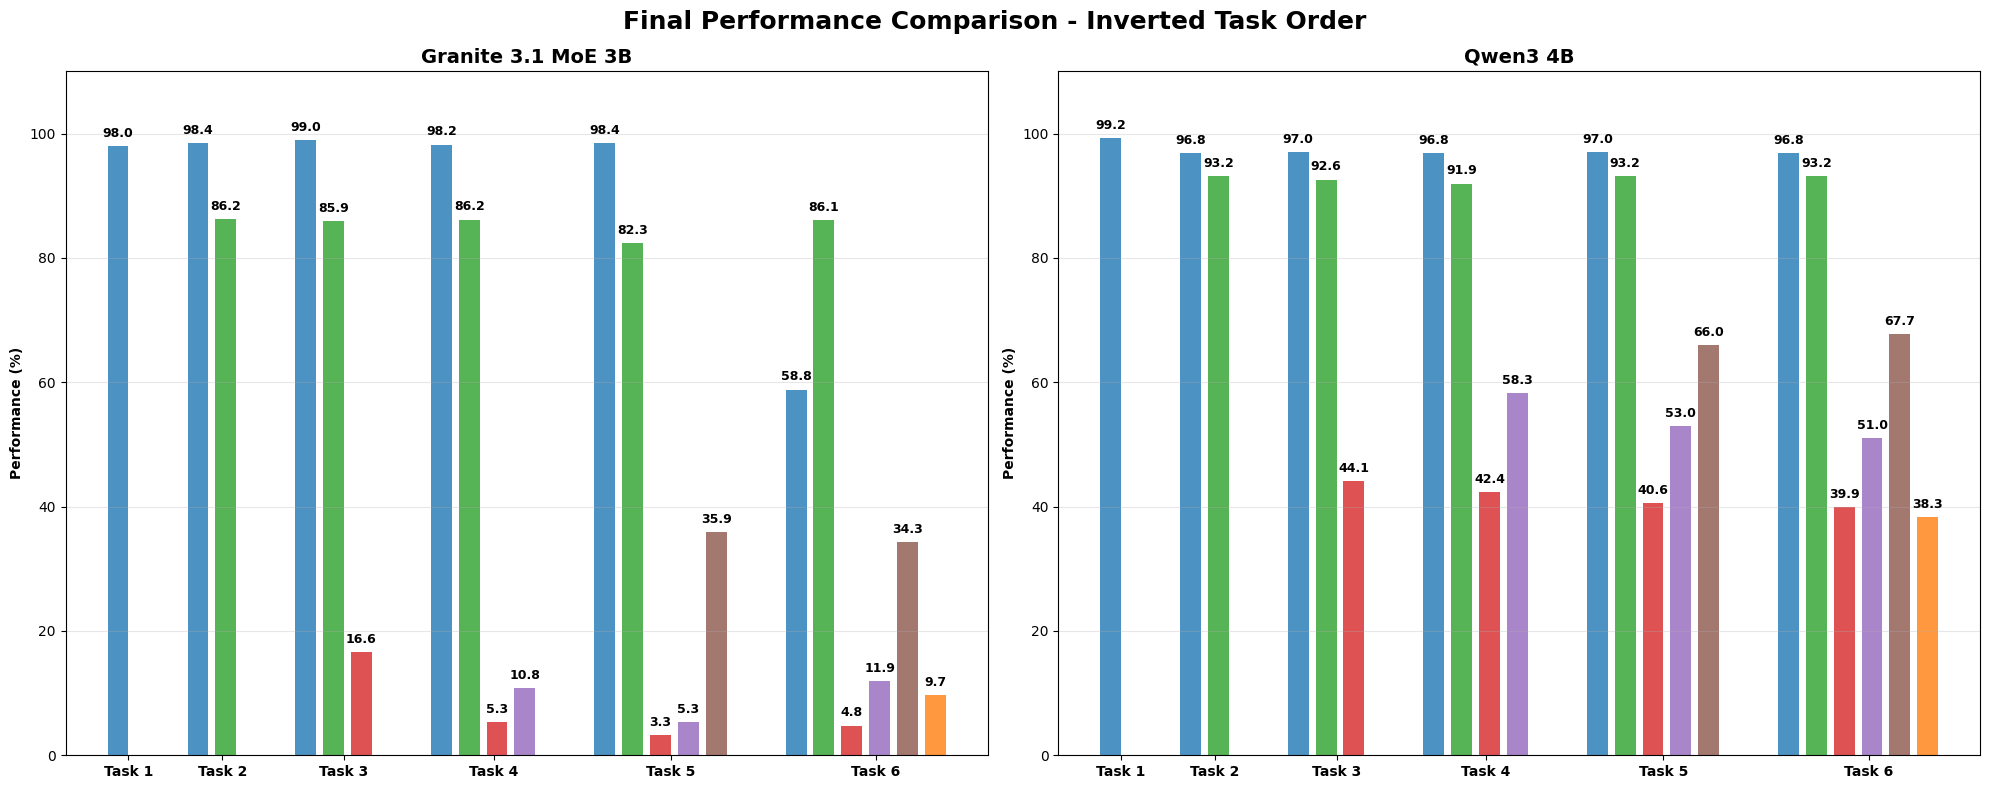

✅ Grafico comparativo invertito salvato

🎨 2. Grafico performance change invertito...
Granite 3.1 MoE 3B - json_em: 98.0% → 58.8% (degradazione: -40.0%)
Granite 3.1 MoE 3B - em_sentiment: 86.2% → 86.1% (degradazione: -0.1%)
Granite 3.1 MoE 3B - em_emotion: 16.6% → 4.8% (degradazione: -71.3%)
Granite 3.1 MoE 3B - em_topic: 10.8% → 11.9% (miglioramento: +10.3%)
Granite 3.1 MoE 3B - f1_ner: 35.9% → 34.3% (degradazione: -4.4%)
Granite 3.1 MoE 3B - Degradazione medio: -21.1%

Qwen3 4B - json_em: 99.2% → 96.8% (degradazione: -2.4%)
Qwen3 4B - em_sentiment: 93.2% → 93.2% (degradazione: +0.0%)
Qwen3 4B - em_emotion: 44.1% → 39.9% (degradazione: -9.6%)
Qwen3 4B - em_topic: 58.3% → 51.0% (degradazione: -12.4%)
Qwen3 4B - f1_ner: 66.0% → 67.7% (miglioramento: +2.6%)
Qwen3 4B - Degradazione medio: -4.4%



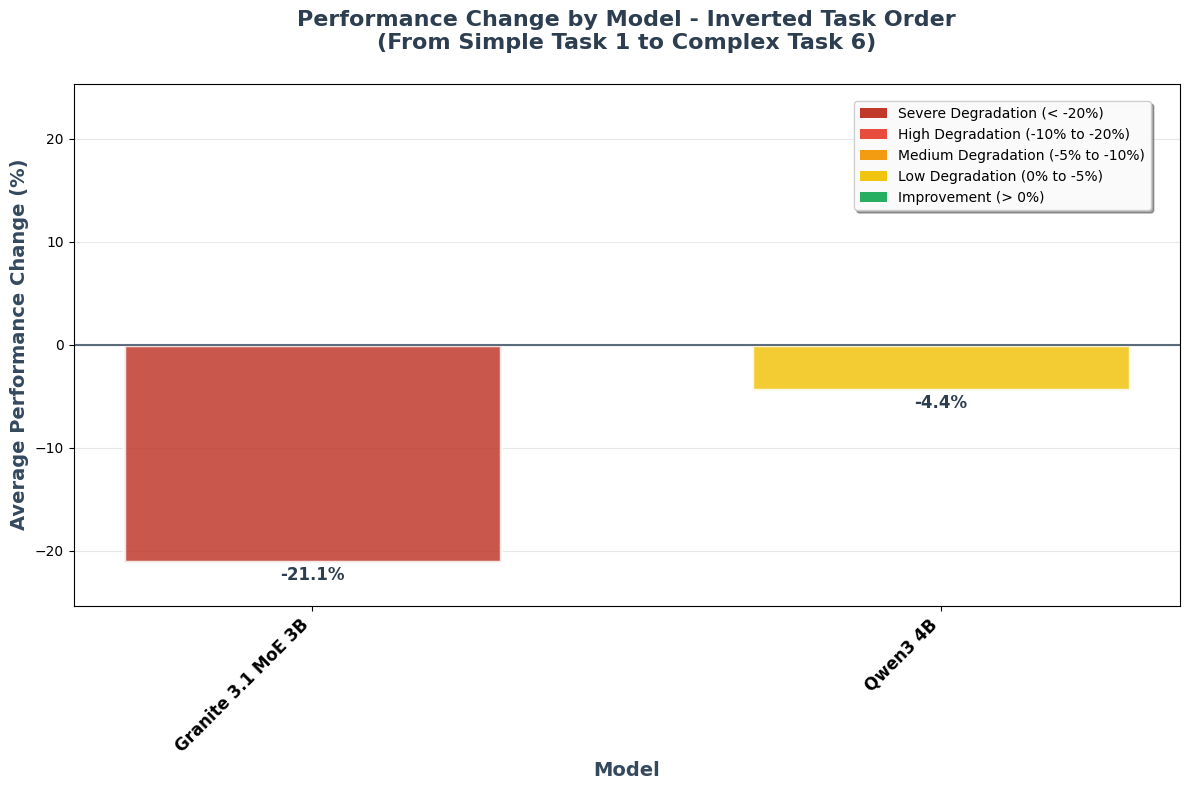

✅ Grafico performance change invertito salvato

💾 Salvataggio riassunto dati...
✅ CSV riassuntivo salvato: ../Output Performance Degradation Analysis/inverted_model_summary.csv

✅ ANALISI ORDINE INVERTITO COMPLETATA!
📁 Output salvato in: ../Output Performance Degradation Analysis/

📊 File generati:
     - models_table.png
     - multi_model_final_performance_comparison_inverted.png
     - overall_model_performance_change_analysis_inverted.png
     - inverted_model_summary.csv


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

def create_models_table(output_dir):
    """Crea una tabella PNG seguendo esattamente lo schema fornito."""
    
    # Dati con colonna Family estratta dalle parentesi
    models_data = [
        ['qwen3:4b-instruct', '088c6bc07f1d', '2.5 GB', 'Alibaba'],
        ['gemma3:4b', 'a2af6cc3eb7f', '3.3 GB', 'Google DeepMind'],
        ['llama3.1:8b-instruct-q3_K_M', '4faa21fca5a2', '4.0 GB', 'Meta'],
        ['mistral:7b-instruct', '6577803aa9a0', '4.4 GB', 'Mistral AI'],
        ['deepseek-r1:7b', '755ced02ce7b', '4.7 GB', 'DeepSeek AI'],
        ['granite3.1-moe:3b', 'b43d80d7fca7', '2.0 GB', 'IBM']
    ]
    
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.axis('off')
    
    # Header con colonna Family
    headers = ['NAME', 'ID', 'SIZE', 'FAMILY']
    
    # Crea tabella con colonne ottimizzate per 4 colonne
    table = ax.table(cellText=models_data,
                    colLabels=headers,
                    cellLoc='left',
                    loc='center',
                    colWidths=[0.25, 0.10, 0.08, 0.14])  # Proporzioni per 4 colonne
    
    # Styling minimalista
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)
    
    # Bordi semplici
    for key, cell in table.get_celld().items():
        cell.set_linewidth(1)
        cell.set_edgecolor('black')
        cell.set_facecolor('white')
        
        row, col = key
        if row == 0:  # Header
            cell.set_text_props(weight='bold')
        else:
            if col == 1:  # ID column - monospace
                cell.set_text_props(fontfamily='monospace', fontsize=8)
    
    # Titolo
    plt.suptitle('Used Large Language Models Details', 
             fontsize=12, fontweight='bold', y=0.90, x=0.5, ha='center')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/models_table.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Tabella modelli salvata")

# =============================================================================
# CONFIGURAZIONE MODELLI INVERTITI
# =============================================================================

# Solo i 2 modelli con ordine invertito
INVERTED_MODELS = {
    'granite3.1-moe:3b': 'granite3.1-moe_3b',
    'qwen3:4b-instruct': 'qwen3_4b-instruct'
}

# Nomi semplificati
INVERTED_MODEL_DISPLAY_NAMES = {
    'granite3.1-moe_3b': 'Granite 3.1 MoE 3B',
    'qwen3_4b-instruct': 'Qwen3 4B'
}

# Task names per ordine invertito - ORDINE CORRETTO
TASK_NAMES = {
    1: "json_only",
    2: "json_sentiment", 
    3: "json_sentiment_emotion",
    4: "json_sentiment_emotion_topic",
    5: "json_sentiment_emotion_topic_ner",
    6: "json_sentiment_emotion_topic_ner_translation"
}

BASE_DIR = "../Output Performance Degradation Analysis"

# Colori per i modelli
INVERTED_MODEL_COLORS = {
    'granite3.1-moe_3b': '#8c564b',     # Marrone
    'qwen3_4b-instruct': '#1f77b4'      # Blu
}

# Colori per le metriche (stessi dell'originale)
METRIC_COLORS = {
    'json_em': '#1f77b4',
    'bleu_translate': '#ff7f0e',
    'em_sentiment': '#2ca02c',
    'em_emotion': '#d62728',
    'em_topic': '#9467bd',
    'f1_ner': '#8c564b'
}

print(f"Configurazione completata per {len(INVERTED_MODELS)} modelli invertiti")
print("Ordine task invertito:")
for task_num, task_name in TASK_NAMES.items():
    print(f"  Task {task_num}: {task_name}")

# =============================================================================
# FUNZIONI DI CARICAMENTO DATI
# =============================================================================

def load_inverted_model_data():
    """Carica i dati dei modelli invertiti dai CSV summary."""
    inverted_data = {}
    
    for model_name, model_clean in INVERTED_MODELS.items():
        csv_path = f"{BASE_DIR}/evaluation_summary_invert_{model_clean}_6tasks.csv"
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                inverted_data[model_clean] = df
                print(f"✓ Caricato invertito: {model_name} ({len(df)} righe)")
            except Exception as e:
                print(f"❌ Errore caricando {model_name}: {e}")
        else:
            print(f"❌ File non trovato: {csv_path}")
    
    return inverted_data

# =============================================================================
# FUNZIONI DI ELABORAZIONE DATI (ADATTATE PER ORDINE INVERTITO)
# =============================================================================

def get_final_performance_data_inverted(all_data):
    """Estrae i dati delle performance finali per ogni modello - ORDINE INVERTITO."""
    final_data = {}
    
    # Task metrics per ordine invertito - ORDINE CORRETTO
    task_metrics = {
        1: ['json_em'],  # Più semplice
        2: ['json_em', 'em_sentiment'],
        3: ['json_em', 'em_sentiment', 'em_emotion'],
        4: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic'],
        5: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner'],
        6: ['json_em', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner', 'bleu_translate']  # Più complesso
    }
    
    for model_name, df in all_data.items():
        model_data = {}
        
        for task in range(1, 7):
            task_df = df[df['task_number'] == task]
            if not task_df.empty:
                last_row = task_df.iloc[-1]
                
                task_data = {}
                for metric in task_metrics[task]:
                    value = last_row[metric] if metric in last_row and pd.notna(last_row[metric]) else 0
                    task_data[metric] = value
                
                model_data[task] = task_data
        
        final_data[model_name] = model_data
    
    return final_data

# =============================================================================
# GRAFICI PER ORDINE INVERTITO
# =============================================================================

def create_final_performance_comparison_inverted(final_data, output_dir):
    """Crea grafici delle performance finali per ordine invertito."""
    
    # Task metrics CORRETTI per ordine invertito
    task_metrics = {
        1: [('json_em', 'JSON EM')],  # Più semplice
        2: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM')],
        3: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM')],
        4: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM')],
        5: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')],
        6: [('json_em', 'JSON EM'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1'), ('bleu_translate', 'BLEU Trans')]  # Più complesso
    }
    
    model_names = list(final_data.keys())
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('Final Performance Comparison - Inverted Task Order', fontsize=18, fontweight='bold')
    
    for idx, model_name in enumerate(model_names):
        ax = axes[idx]
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        
        model_data = final_data[model_name]
        
        current_position = 0
        bar_width = 0.6
        group_spacing = 1.5
        all_positions = []
        all_labels = []
        
        for task in range(1, 7):
            task_start_pos = current_position
            
            for i, (metric_key, metric_label) in enumerate(task_metrics[task]):
                pos = current_position
                
                value = 0
                if task in model_data and metric_key in model_data[task]:
                    value = model_data[task][metric_key]
                
                color = METRIC_COLORS[metric_key]
                
                bar = ax.bar(pos, value, width=bar_width, color=color, alpha=0.8)
                
                if value > 0:
                    ax.text(pos, value + 1, f'{value:.1f}', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
                
                current_position += bar_width + 0.2
            
            task_center = task_start_pos + (len(task_metrics[task]) * (bar_width + 0.2) - 0.2) / 2
            all_positions.append(task_center)
            all_labels.append(f'Task {task}')
            
            current_position += group_spacing
        
        ax.set_xticks(all_positions)
        ax.set_xticklabels(all_labels, rotation=0, ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{model_display}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Performance (%)', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 110)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/multi_model_final_performance_comparison_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico comparativo invertito salvato")

def create_overall_degradation_chart_inverted(final_data, output_dir):
    """Crea grafico di performance change per ordine invertito."""
    
    degradation_results = {}
    
    # Metriche per calcolo degradazione - ORDINE INVERTITO CORRETTO (da Task 1 semplice a Task 6 complesso)
    metrics_for_degradation = {
        'json_em': (1, 6),          # Da semplice (1) a complesso (6) 
        'em_sentiment': (2, 6),     # Da quando appare per la prima volta
        'em_emotion': (3, 6),
        'em_topic': (4, 6),
        'f1_ner': (5, 6)
        # bleu_translate solo in Task 6, non possiamo calcolare degradazione
    }
    
    for model_name, model_data in final_data.items():
        model_display = INVERTED_MODEL_DISPLAY_NAMES[model_name]
        degradations = []
        
        for metric, (start_task, end_task) in metrics_for_degradation.items():
            if start_task in model_data and end_task in model_data:
                start_value = model_data[start_task].get(metric, 0)  # Task più semplice
                end_value = model_data[end_task].get(metric, 0)      # Task più complesso
                
                if start_value > 0:
                    # Formula: ((finale - iniziale) / iniziale) * 100
                    change_pct = ((end_value - start_value) / start_value) * 100
                    degradations.append(change_pct)
                    status = "miglioramento" if change_pct > 0 else "degradazione"
                    print(f"{model_display} - {metric}: {start_value:.1f}% → {end_value:.1f}% ({status}: {change_pct:+.1f}%)")
        
        if degradations:
            avg_change = sum(degradations) / len(degradations)
            degradation_results[model_display] = {
                'avg_change': avg_change,
                'individual_changes': degradations,
                'n_metrics': len(degradations)
            }
            status = "miglioramento" if avg_change > 0 else "degradazione"
            print(f"{model_display} - {status.title()} medio: {avg_change:+.1f}%\n")
    
    # Crea grafico
    sorted_models = sorted(degradation_results.items(), 
                          key=lambda x: x[1]['avg_change'])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    models = [item[0] for item in sorted_models]
    values = [item[1]['avg_change'] for item in sorted_models]
    
    colors = []
    for val in values:
        if val < -20:
            colors.append('#c0392b')
        elif val < -10:
            colors.append('#e74c3c')
        elif val < -5:
            colors.append('#f39c12')
        elif val < 0:
            colors.append('#f1c40f')
        else:
            colors.append('#27ae60')
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=2.5, width=0.6)
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val >= 0:
            y_pos = bar.get_height() + max(abs(max(values)), abs(min(values))) * 0.02
            va = 'bottom'
        else:
            y_pos = bar.get_height() - max(abs(max(values)), abs(min(values))) * 0.02
            va = 'top'
            
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', va=va, 
                fontsize=12, fontweight='bold', color='#2c3e50')
    
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.8)
    
    ax.set_title('Performance Change by Model - Inverted Task Order\n(From Simple Task 1 to Complex Task 6)', 
                fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
    ax.set_xlabel('Model', fontsize=14, fontweight='bold', color='#34495e')
    ax.set_ylabel('Average Performance Change (%)', fontsize=14, fontweight='bold', color='#34495e')
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    if values:
        y_max = max(abs(max(values)), abs(min(values))) * 1.2
        ax.set_ylim(-y_max, y_max)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
    ax.set_axisbelow(True)
    
    # Legenda semplificata
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#c0392b', label='Severe Degradation (< -20%)'),
        Patch(facecolor='#e74c3c', label='High Degradation (-10% to -20%)'),
        Patch(facecolor='#f39c12', label='Medium Degradation (-5% to -10%)'),
        Patch(facecolor='#f1c40f', label='Low Degradation (0% to -5%)'),
        Patch(facecolor='#27ae60', label='Improvement (> 0%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
             fontsize=10, framealpha=0.95, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overall_model_performance_change_analysis_inverted.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ Grafico performance change invertito salvato")

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    print("=" * 80)
    print("ANALISI PERFORMANCE - ORDINE INVERTITO")
    print("=" * 80)
    
    # Carica dati
    print("\n📥 Caricamento dati invertiti...")
    inverted_data = load_inverted_model_data()
    
    if not inverted_data:
        print("❌ Nessun dato invertito trovato!")
        return
    
    # Elabora dati
    print("\n📈 Elaborazione dati invertiti...")
    inverted_final = get_final_performance_data_inverted(inverted_data)
    
    # Crea directory output
    output_dir = f"{BASE_DIR}"
    os.makedirs(output_dir, exist_ok=True)
    print(f"📁 Directory output: {output_dir}")
    
    print("\n" + "="*60)
    print("GENERAZIONE GRAFICI ORDINE INVERTITO")
    print("="*60)
    
    # Tabella modelli
    print("\n📋 0. Tabella modelli utilizzati...")
    create_models_table(output_dir)
    
    # Grafici per ordine invertito
    print("\n🎨 1. Grafico comparativo performance finali invertito...")
    create_final_performance_comparison_inverted(inverted_final, output_dir)
    
    print("\n🎨 2. Grafico performance change invertito...")
    create_overall_degradation_chart_inverted(inverted_final, output_dir)
    
    # Salva riassunto
    print("\n💾 Salvataggio riassunto dati...")
    summary_rows = []
    for model_name, model_data in inverted_final.items():
        for task, metrics in model_data.items():
            for metric, value in metrics.items():
                summary_rows.append({
                    'model': INVERTED_MODEL_DISPLAY_NAMES[model_name],
                    'task': task,
                    'metric': metric,
                    'value': value,
                    'order': 'inverted'
                })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f'{output_dir}/inverted_model_summary.csv', index=False)
    print(f"✅ CSV riassuntivo salvato: {output_dir}/inverted_model_summary.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANALISI ORDINE INVERTITO COMPLETATA!")
    print("=" * 80)
    print(f"📁 Output salvato in: {output_dir}/")
    print("\n📊 File generati:")
    print("     - models_table.png")
    print("     - multi_model_final_performance_comparison_inverted.png")
    print("     - overall_model_performance_change_analysis_inverted.png")
    print("     - inverted_model_summary.csv")

if __name__ == "__main__":
    main()